In [1]:
import os
os.environ['JAX_PLATFORMS'] = 'cpu'

# import os
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'


# This is required to run multiple processes with JAX.
from multiprocessing import set_start_method
set_start_method('forkserver', force=True)

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from tqdm import tqdm
from pathlib import Path

# jax.config.update("jax_disable_jit", True)

from config import Config
import data

In [3]:
run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/gmm/era5_zstd_20251021_234237")

In [4]:
from train import Trainer
trainer = Trainer.load_last_checkpoint(run_dir)

Model contains 439,224 parameters
Loading trainer from checkpoint step_076000
Logging at /nas/cee-water/cjgleason/ted/swot-ml/runs/gmm/era5_zstd_20251021_234237


In [5]:
cfg = trainer.cfg
cfg.quiet = False
mgr = data.DynamicCacheManager(cfg)
cache_dir = mgr.create_cache('test')
dataset = data.CachedBasinGraphDataset(cfg, cache_dir, 'test')

Caches will be stored at: /scratch3/workspace/tlanghorst_umass_edu-swot-ml-zarr2/20251004/_cache/12f3c9c9b5b17993/<subset>


Loading basins: 100%|██████████| 46/46 [00:00<00:00, 3854.37it/s]

Wrote 0 new basin files to cache.
✅ Cached resources are loaded and ready.
Calculating training statistics for encoding and normalization...


Loading static attributes...Done!
Loading basin graphs...Done!


Building sampling index: 100%|██████████| 46/46 [00:24<00:00,  1.87it/s]


In [6]:
cfg.num_workers = 0
dataloader = data.CachedBasinGraphDataLoader(cfg, dataset)

Dataloader using 0 parallel CPU worker(s).


In [ ]:
for basin, date, batch in tqdm(dataloader):
    break

from evaluate.inference import model_iterate
model_iter = model_iterate(trainer.model, dataloader)
out = next(model_iter)


In [8]:
out['y_pred']

{'discharge': array([ 4.8802414,  5.206833 ,  1.8685455, ...,  2.9605408,  4.3092957,
        15.37402  ], dtype=float32),
 'discharge_std': array([56.6096  , 58.503498, 39.891552, ..., 47.635136, 64.750565,
        86.56875 ], dtype=float32)}

In [26]:
results_dir = run_dir / 'results'
results_dir.mkdir(exist_ok = True)

import evaluate
evaluate.inference.predict_to_parquet(trainer.model, dataloader, results_dir / 'test_out.parquet')


100%|██████████| 16/16 [03:49<00:00, 14.32s/it]

Results successfully written to /nas/cee-water/cjgleason/ted/swot-ml/runs/test/era5_swot_gmm_20251021_200026/results/test_out.parquet


In [36]:
df = pd.read_parquet(results_dir / 'test_out.parquet')
df

pred                      obs
                                          discharge discharge_std  discharge
basin          subbasin       date                                          
USGS-02428400  USGS-02379500  2024-03-21   8.450442      1.085990   8.636638
               USGS-02380500  2024-03-21  13.863086      1.050682  14.526543
               USGS-02382500  2024-03-21  13.109510      1.064102  42.758438
               USGS-02383500  2024-03-21  13.124351      1.075221  55.784180
               USGS-02384500  2024-03-21   8.781009      1.051130   9.684361
...                                             ...           ...        ...
ABOM-320099010 ABOM-320099010 2024-04-10   1.557358      1.072745   0.773000
               ABOM-321906010 2024-04-10   2.296529      1.040233   1.309000
               ABOM-320099010 2023-07-08   2.066553      1.073647   9.160000
               ABOM-320907010 2023-07-08   1.118292      1.215434   0.001000
               ABOM-320099010 2023-10-20   0.950463      1.148173   1.901000

[40235 rows x 3 columns]

In [44]:
basin_metrics = evaluate.metrics.get_basin_metrics(df, True)

Basin Metrics
DISCHARGE
num_obs: 641.0000
R2: -0.1026
NSE: -0.1026
KGE: -0.0678
sigE: 0.7547
rRMSE: 137.1645
MAPE: 97.1024
nBias: 15.5762
RE: 171.8109
RB: 15.5762
Agreement: 0.3792




In [47]:
basin_metrics['discharge']['NSE'].sort_values()

USGS-0242354750   -251.629944
USGS-02423414      -67.054466
USGS-02387600      -31.982471
USGS-02423160      -29.628515
USGS-02390140      -29.072903
                      ...    
USGS-02388350        0.415674
USGS-02423500        0.474186
USGS-02423555        0.500048
USGS-02385170        0.503924
USGS-02411930        0.656322
Name: NSE, Length: 64, dtype: object

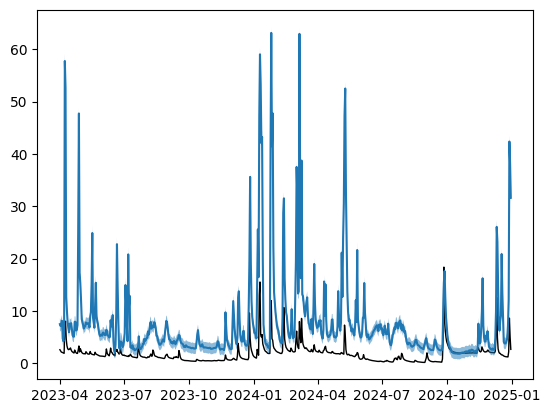

In [58]:
bs = df.xs('USGS-02390140', level='subbasin').sort_index()
bs.index = bs.index.get_level_values('date')

x = bs.index
y = bs['pred']['discharge']
error = bs['pred']['discharge_std']
plt.plot(x, y)
plt.fill_between(x, y-error, y+error, alpha=0.5, facecolor='tab:blue', antialiased=True)

plt.plot(bs.index, bs['obs']['discharge'], color='black', linewidth=1, zorder=0)

In [8]:
for basin, date, batch in tqdm(dataloader):
    break

  0%|          | 0/5377 [00:05<?, ?it/s]


In [8]:
import evaluate
import equinox as eqx

@eqx.filter_jit
def _model_map(model, batch, key):
    """Applies the model to a batch of data using jax.vmap."""
    y_pred = model(batch, key)
    return y_pred

model = eqx.nn.inference_mode(trainer.model)
# Dummy key (only used for dropout, which we just turned off).
key = jax.random.PRNGKey(0)
for basin, date, batch in tqdm(dataloader, disable=cfg.quiet):
    batch = batch.to_jax()
    y_pred = _model_map(model, batch, key)
    break

  0%|          | 0/5377 [00:13<?, ?it/s]


In [9]:
y_pred['discharge']['pi'].shape

(7000, 100)

In [20]:
from functools import partial
denormalize = True
denorm_fn = partial(dataloader.denormalize, name='discharge') if denormalize else None

denorm_fn

functools.partial(<bound method CachedBasinGraphDataLoader.denormalize of <data.cached_basingraphdataloader.CachedBasinGraphDataLoader object at 0x761faeec03d0>>, name='discharge')

In [24]:
dist_pred = y_pred['discharge']
node_mask = batch.node_mask

mu = np.asarray(dist_pred['mu'][node_mask])
sigma = np.asarray(dist_pred['sigma'][node_mask])
pi = np.asarray(dist_pred['pi'][node_mask])

mu_exp = np.sum(pi * mu, axis=-1)

# Expected variance
var_exp = np.sum(
    pi * (sigma**2 + (mu - mu_exp[..., None])**2),
    axis=-1
)
std_exp = np.sqrt(var_exp)


In [25]:
denorm_fn(std_exp)

array([ 9.861439 , 14.291063 ,  6.2113514, ...,  6.3901496,  6.518851 ,
        5.725848 ], dtype=float32)

In [28]:
for t_name, t_dist in y_pred.items():
    mu_exp = jnp.sum(t_dist['pi'] * t_dist['mu'], axis=-1)

     # Expected variance
    var_exp = jnp.sum(
        t_dist['pi'] * (t_dist['sigma']**2 + (t_dist['mu'] - mu_exp[..., None])**2),
        axis=-1
    )

    y_pred[t_name]['sigma_exp'] = jnp.sqrt(var_exp)
    y_pred[t_name]['mu_exp'] = mu_exp
    

In [47]:
import models

head_type = type(list(model.head.values())[0])

head_type == models.layers.heads.GMM

True

In [49]:
match head_type:
    case models.layers.heads.GMM:
        print('true')
    case _:
        print("false")

false


In [10]:
import evaluate

model_iter = evaluate.inference.model_iterate(trainer.model, dataloader)

out_dict = next(model_iter)

  0%|          | 0/5377 [00:00<?, ?it/s]

In [21]:
from collections import defaultdict

# inference_mode = dataloader.dataset.inference_mode
basins = []
dates = []
y_preds = defaultdict(list)
ys = defaultdict(list)

# Iterate through the dataset, make predictions and collect data in lists.
count = 0
for result_dict in evaluate.inference.model_iterate(trainer.model, dataloader, False, True):
    basins.extend(result_dict["basin"])
    dates.extend(result_dict["date"])

    for name, arr in result_dict['y_pred'].items():
        y_preds[name].append(arr)

    for name, arr in result_dict.get('y', {}).items():
        ys[name].append(arr)

    count += 1
    if count == 2:
        break


  0%|          | 1/5377 [00:19<29:30:00, 19.75s/it]


In [38]:
y_pred_arrs = {name: np.concatenate(arr_list) for name, arr_list in y_preds.items()}
y_arrs = {name: np.concatenate(arr_list) for name, arr_list in ys.items()}


In [ ]:
if len(y_arrs) > 0:
    data = np.concatenate((y_arr, y_hat_arr), axis=-1)
    cols = ["obs", "pred"]
else:
    data = y_hat_arr
    cols = ["pred"]

In [41]:
data = {'obs': y_arrs, 'pred': y_pred_arrs}

data

{'obs': {'discharge': array([       nan,        nan,        nan, ..., 28.604992 ,  1.3629998,
          3.6699998], dtype=float32)},
 'pred': {'discharge': array([14.921872 ,  5.436517 ,  3.3159995, ..., 46.80532  , 16.287468 ,
          3.1303098], dtype=float32),
  'discharge_std': array([1.5422773, 1.3945414, 1.8732612, ..., 2.163427 , 1.548627 ,
         1.6137323], dtype=float32)}}

In [48]:
subbasin_map = dataloader.dataset.basin_subbasin_map  # dict[str: list[str]]
rows = [
    (basin, subbasin, date)
    for basin, date in zip(basins, dates)
    for subbasin in subbasin_map[basin]
]
row_index = pd.MultiIndex.from_tuples(rows, names=["basin", "subbasin", "date"])

MultiIndex([('USGS-02198500',      '73011097', '2012-02-12'),
            ('USGS-02198500',      '73011108', '2012-02-12'),
            ('USGS-02198500',      '73011137', '2012-02-12'),
            ('USGS-02198500',      '73011241', '2012-02-12'),
            ('USGS-02198500',      '73011274', '2012-02-12'),
            ('USGS-02198500',      '73011314', '2012-02-12'),
            ('USGS-02198500',      '73011628', '2012-02-12'),
            ('USGS-02198500',      '73012065', '2012-02-12'),
            ('USGS-02198500',      '73012102', '2012-02-12'),
            ('USGS-02198500',      '73012117', '2012-02-12'),
            ...
            (  'UKEA-055036',   'UKEA-055018', '2012-04-04'),
            (  'UKEA-055036',   'UKEA-055021', '2012-04-04'),
            (  'UKEA-055036',   'UKEA-055028', '2012-04-04'),
            (  'UKEA-055036',   'UKEA-055036', '2012-04-04'),
            ('ABOM-15573010', 'ABOM-15493010', '2001-02-15'),
            ('ABOM-15573010', 'ABOM-15573010', '2001-0

In [49]:
df = pd.concat({outer: pd.DataFrame(inner) for outer, inner in data.items()}, axis=1)
df.index = row_index

df

obs        pred              
                                         discharge   discharge discharge_std
basin         subbasin      date                                            
USGS-02198500 73011097      2012-02-12         NaN   14.921872      1.542277
              73011108      2012-02-12         NaN    5.436517      1.394541
              73011137      2012-02-12         NaN    3.316000      1.873261
              73011241      2012-02-12         NaN    3.721600      1.400327
              73011274      2012-02-12         NaN    2.528844      1.515653
...                                            ...         ...           ...
ABOM-15573010 ABOM-15573010 2001-02-15  176.558990  126.381378      2.370795
              ABOM-15493010 2014-04-02   24.197001   39.110916      1.616221
              ABOM-15573010 2014-04-02   28.604992   46.805321      2.163427
              ABOM-15493010 2004-07-21    1.363000   16.287468      1.548627
              ABOM-15573010 2004-07-21    3.670000    3.130310      1.613732

[13992 rows x 3 columns]

In [26]:
np.concatenate(ys['discharge'])

array([       nan,        nan,        nan, ..., 28.604992 ,  1.3629998,
        3.6699998], dtype=float32)

In [ ]:
basins = []
dates = []
y_hat_list = []
y_list = []

In [14]:
out_dict['y_pred']

{'discharge': array([167.74762  ,  16.747335 ,  29.238657 , ...,   1.8358228,
          2.487331 ,   0.7810037], dtype=float32),
 'discharge_std': array([1.9240278, 1.9174194, 1.62079  , ..., 3.0364213, 2.6221604,
        1.9627265], dtype=float32)}

In [11]:
out_dict['y_pred']

{'discharge': array([167.74762  ,  16.747335 ,  29.238657 , ...,   1.8358228,
          2.487331 ,   0.7810037], dtype=float32),
 'discharge_std': array([1.9240278, 1.9174194, 1.62079  , ..., 3.0364213, 2.6221604,
        1.9627265], dtype=float32)}

In [34]:
batch.y['discharge'][-1, ..., 0][batch.node_mask]

Array([       nan,        nan,        nan, ...,  2.0908306, -0.5604849,
        0.631315 ], dtype=float32)

In [36]:
type(trainer.model.head['discharge'])

models.layers.heads.GMM

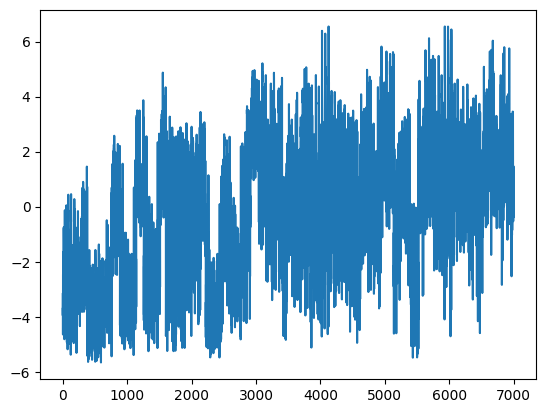

In [31]:
y_pred['discharge']['mu_exp']

In [58]:
batch.node_mask.shape

(7000,)

In [59]:
batch.y.shape

(90, 7000, 1)

In [27]:
y_pred.shape

(90, 7000, 1)

In [34]:
if len(y_pred.shape) == 3:
    y_hat = y_pred[-1,...]

expanded_node_mask = batch.node_mask[:, None]
# expanded_node_mask = jnp.broadcast_to(expanded_node_mask, y_pred.shape)
expanded_node_mask.shape

(7000, 1)

In [40]:
expanded_node_mask.shape

(7000, 1)

In [35]:
batch.y.shape

(90, 7000, 1)

In [45]:
y = batch.y[-1,...][batch.node_mask, :]

y.shape

(6999, 1)

In [38]:
y_hat[expanded_node_mask].shape

(6999,)

In [8]:
import evaluate
results_dir = run_dir / 'results'
results_dir.mkdir(exist_ok=True)
results_file =  results_dir / 'test_results.parquet'
evaluate.predict_to_parquet(trainer.model, dataloader, results_file, quiet=cfg.quiet)

100%|██████████| 1248/1248 [3:02:55<00:00,  8.79s/it]

Results successfully written to /nas/cee-water/cjgleason/ted/swot-ml/runs/global_mutligraph/era5_swot_20251008_120327/test_results.parquet


In [55]:
state = jax.random.uniform(key, (90, 7000, 1))
state.shape

(90, 7000, 1)

In [10]:
results = pd.read_parquet(run_dir / 'results' / 'test_results.parquet')
results

Type                                           obs        pred
Feature                                  discharge   discharge
basin          subbasin       date                            
USGS-02428400  73011033       2023-01-14       NaN  270.050018
               73011035       2023-01-14       NaN   47.630356
               73011044       2023-01-14       NaN   20.895082
               73011045       2023-01-14       NaN   62.892376
               73011109       2023-01-14       NaN   61.054600
...                                            ...         ...
USGS-01589035  USGS-01589035  2020-07-26  2.038813    3.987706
ABOM-281030010 ABOM-281030010 2023-03-24  0.094000    0.278067
ABOM-224727010 ABOM-224727010 2024-03-01  0.006000    0.015271
ABOM-132541010 ABOM-132541010 2024-02-02  4.341001    6.984094
USGS-12048000  USGS-12048000  2021-08-20  3.737824    6.027794

[8730990 rows x 2 columns]

In [11]:
import evaluate
basin_m = evaluate.get_basin_metrics(results)

In [12]:
basin_m['discharge']['sigE'].dropna().sort_values()

EAUF-J5712110      0.000158
USGS-08206600      0.020298
ABOM-24994010      0.042928
USGS-08099300      0.049521
USGS-08086500      0.049829
                    ...    
EAUF-Y1445010    146.276527
USGS-12465400     151.32021
USGS-01636690    193.523068
USGS-12452550    226.405108
ECCC-08NJ026     243.051076
Name: sigE, Length: 1482, dtype: object

In [33]:
basin_m['discharge']['NSE'].dropna()

ABOM-103650010            0.178576
ABOM-103731010            0.008574
ABOM-103893010           -4.710195
ABOM-104162010           -0.052334
ABOM-104348010            0.383703
                           ...    
USGS-261543080495000    -13.563363
USGS-261808081042800     -4.378637
USGS-262038080584600   -179.250717
USGS-50035000            -0.067421
USGS-50037000             0.031573
Name: NSE, Length: 1482, dtype: object

In [47]:
import geopandas as gpd
save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/reservoirs")
metadata_dir = save_dir / "metadata"
matchups = gpd.read_parquet(metadata_dir / "All_MERIT_matchups.parquet").set_index('comid')
matchups.index = matchups.index.astype(str)

In [50]:
list(matchups.dropna(subset='mean_discharge'))

['outlet',
 'outlet_id',
 'total_area',
 'unitarea',
 'reservoir',
 'custom',
 'reach_id',
 'sword_area',
 'sword_distance',
 'lake_reach_ids',
 'lake_pld_ids',
 's2m_values',
 'name',
 'area',
 'latitude',
 'longitude',
 'min_date',
 'max_date',
 'min_discharge',
 'max_discharge',
 'mean_discharge',
 'count_discharge',
 'provider',
 'hybas_area_diff',
 'geometry']

In [53]:
matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,longitude,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9..."
21000012,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0..."
21000019,POINT (5.684999999999993 47.53416666666667),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5..."
21000021,POINT (5.76916666666666 47.58083333333334),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6..."
21000022,POINT (5.80416666666666 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-410401112134801,POINT (-112.1875 41.0625),USGS-410401112134801,9900.3,296.5,False,True,NaN,NaN,NaN,[],...,-112.230256,2003-10-01,2025-09-08,0.006230,45.873291,11.263905,7165.0,usgs,-0.002093,"MULTIPOLYGON (((-112.21458 40.96042, -112.2154..."
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,-66.459568,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ..."
USGS-50037000,POINT (-66.5 18.3983),USGS-50037000,429.1,83.4,False,True,NaN,NaN,NaN,[],...,-66.496560,2019-06-13,2025-09-08,1.265763,911.802460,11.017469,2247.0,usgs,0.167805,"MULTIPOLYGON (((-66.50125 18.33125, -66.50125 ..."


In [37]:
outlets = matchups.copy()
outlets.geometry = gpd.GeoSeries.from_wkt(outlets['outlet']).set_crs('EPSG:4326')

outlet_metrics = outlets.join(basin_m['discharge'], how='inner')

<Axes: >

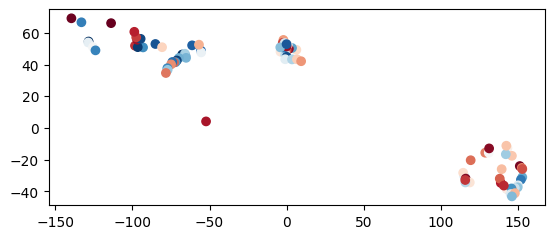

In [38]:
outlet_metrics.plot('NSE', cmap='RdBu')

In [9]:
results

NameError: name 'results' is not defined

<Axes: >

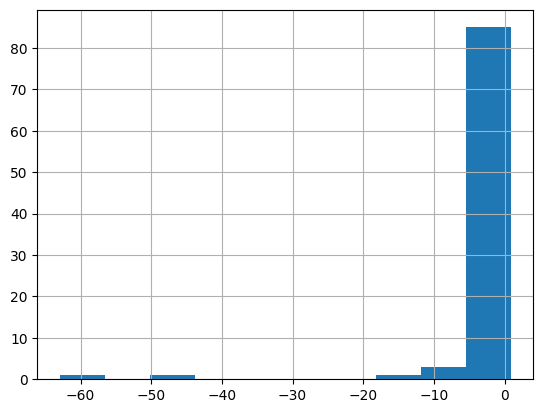

In [44]:
outlet_metrics['NSE'].hist()

In [7]:
with open(run_dir / 'results' / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 1195581,
  'R2': 0.2531314492225647,
  'MAPE': 6111.718368530273,
  'nBias': -1.0169042274355888,
  'RE': 163.2274627685547,
  'RB': -1.0273456573486328,
  'qRE': array([ 57.17298673, 163.22744205, 483.46182911]),
  'qnBias': array([-58.69973451,  -1.01690427, 194.47716177]),
  'MAE': 29.515337,
  'RMSE': 134.3624,
  'rRMSE': 448.8661766052246,
  'KGE': 0.45888651654987755,
  'NSE': 0.2531315352714443,
  'Agreement': 0.509123471526809}}

In [8]:
basin_m['discharge'][['NSE','R2']]

Metric,NSE,R2
ABOM-113192010,0.311099,0.311099
ABOM-117649010,0.137957,0.137957
ABOM-122989010,-0.029531,-0.029531
ABOM-128547010,0.004116,0.004116
ABOM-134767010,0.473615,0.473615
...,...,...
USGS-01371500,0.567267,0.567267
USGS-01465500,0.031238,0.031238
USGS-01673000,0.54105,0.541049
USGS-02047000,0.423409,0.423409


In [92]:
import evaluate

def get_metrics(grp):
   return evaluate.metrics.calc_nse(grp['obs']['discharge'], grp['pred']['discharge'])
df = results.dropna().groupby('subbasin').apply(get_metrics)


<Axes: >

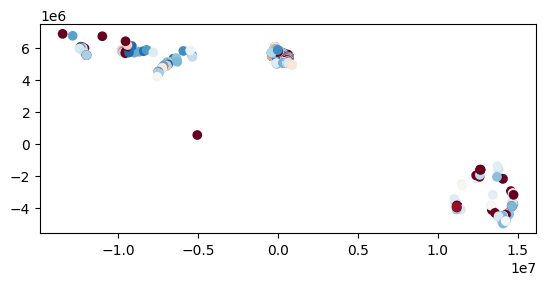

In [99]:
outlet_nse = outlets.join(df.rename('NSE'), how='inner').to_crs("EPSG:6933")

outlet_nse.plot('NSE', vmin=-1, vmax=1, cmap='RdBu')

In [64]:
evaluate.get_all_metrics(grp[1])['discharge']['NSE']

0.1983168125152588

In [51]:
results.dropna()

Type                                           obs      pred
Feature                                  discharge discharge
basin          subbasin       date                          
EAUF-V7200010  EAUF-U0020010  2024-09-18  0.802000  0.044893
               EAUF-U0045004  2024-09-18  0.113000  3.230401
               EAUF-U0104010  2024-09-18  0.715000  4.977508
               EAUF-U0124010  2024-09-18  3.076000  0.972183
               EAUF-U0204001  2024-09-18  0.120000  2.277400
...                                            ...       ...
ABOM-82216010  ABOM-82216010  2022-10-29  0.665000  0.020420
ABOM-280790010 ABOM-280790010 2024-03-26  0.195000  0.045741
EAUF-G0170420  EAUF-G0170420  2022-07-18  4.135000  1.835687
ABOM-189366010 ABOM-189366010 2022-06-23  1.512000  8.235313
EAUF-G0170420  EAUF-G0170420  2023-02-14  5.821001  5.109054

[1195581 rows x 2 columns]

In [19]:
results

Type                                           obs       pred
Feature                                  discharge  discharge
basin          subbasin       date                           
EAUF-V7200010  21000001       2024-09-18       NaN   2.571632
               21000012       2024-09-18       NaN   0.122315
               21000019       2024-09-18       NaN  20.593681
               21000021       2024-09-18       NaN  25.678551
               21000022       2024-09-18       NaN  11.528290
...                                            ...        ...
ABOM-82216010  ABOM-82216010  2022-10-29  0.665000   0.020420
ABOM-280790010 ABOM-280790010 2024-03-26  0.195000   0.045741
EAUF-G0170420  EAUF-G0170420  2022-07-18  4.135000   1.835687
ABOM-189366010 ABOM-189366010 2022-06-23  1.512000   8.235313
EAUF-G0170420  EAUF-G0170420  2023-02-14  5.821001   5.109054

[3467184 rows x 2 columns]

<Axes: xlabel='basin,date'>

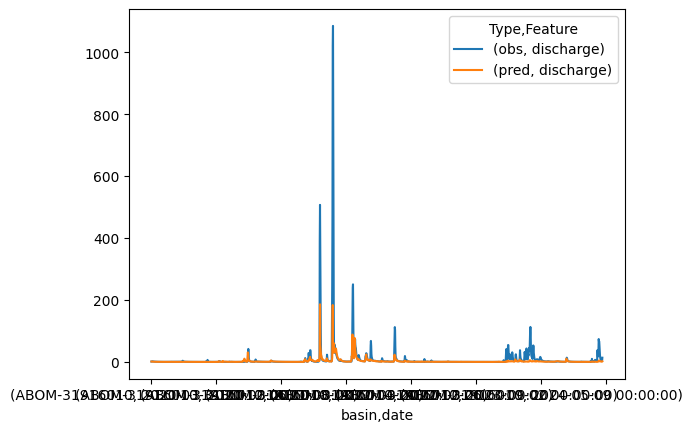

In [25]:
basin = 'ABOM-31916010'

df = results.xs(basin, level='subbasin')
df.sort_index().plot()

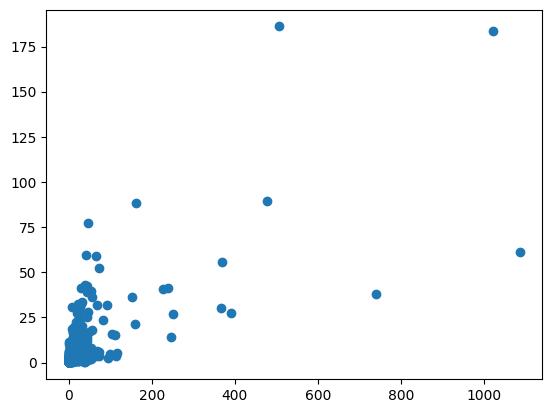

In [30]:
plt.scatter(df['obs']['discharge'], df['pred']['discharge'])

In [24]:
import pickle
with open(results_dir / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 108385,
  'R2': -0.02997457981109619,
  'MAPE': 427.0320415496826,
  'nBias': -0.05712399142794311,
  'RE': 232.67614841461182,
  'RB': -0.05716085433959961,
  'qRE': array([ 73.60065994, 232.67614947, 654.88286463]),
  'qnBias': array([-6.98563695e+01, -5.71239914e-02,  2.33670533e+02]),
  'MAE': 53.644592,
  'RMSE': 194.12527,
  'rRMSE': 1688.498306274414,
  'KGE': -0.3831915309608416,
  'NSE': -0.02997457981109619,
  'Agreement': 0.029437440800148096}}

In [35]:
targets = list(bulk_m.keys())

In [ ]:
import geopandas as gpd
proj_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/distributed")
metadata_dir = proj_dir / "metadata"
basins = gpd.read_file(metadata_dir / 'matchups.geojson').set_index("HYBAS_ID")
basins.index = basins.index.astype(str)
basins

In [ ]:
import evaluate
pred = evaluate.predict(trainer.model, dataloader, denormalize=False)

In [ ]:
pred

In [ ]:
x = pred.xs('2021-02-08', level='date')


x['pred']['discharge']

In [ ]:
x['pred']['discharge'].hist()

In [ ]:
basins_pred = basins.merge(x['pred']['discharge'], left_index=True, right_index=True)
basins_pred.plot('discharge')

In [ ]:
plt.scatter(x['obs']['discharge'], x['pred']['discharge'])
# plt.plot([0,500], [0,500], 'r--')